In [39]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection
from matplotlib import cm
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D    
import matplotlib.patches as mpatches

In [2]:
edge_control=pd.read_csv('experiments/edge/100_traj.csv')
edge_state= pd.read_csv('experiments/edge/edge_states.csv')

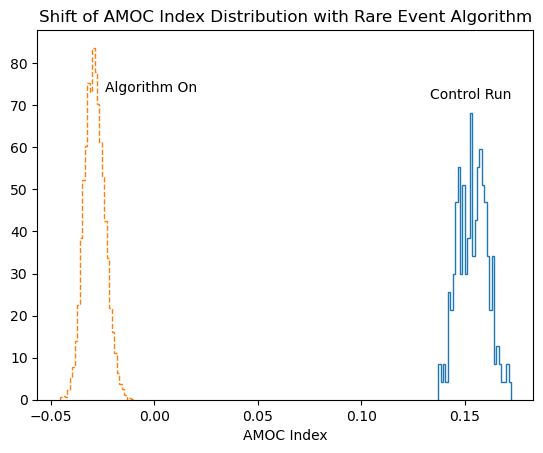

In [7]:
'''
Histogram showing shift of distribution
'''
def get_initials():
    
    #control run initial parameterization
    control_run = pd.read_csv('experiments/control_runs/control_run0505.csv')
    #remove transient
    control_dropped = control_run.loc[control_run['t']>=10]
    #access every 5th row (time unit)
    control_5th = control_dropped.iloc[::500]
    control_5th.head()
    cols = ['x','y','z','T', 'S']
    x_list, y_list, z_list, temp_list, salt_list = [control_5th[c].tolist() for c in cols]

    return x_list,y_list,z_list,temp_list,salt_list
    
#plot distribution change between RE algorithm and initial simulation
x_list,y_list,z_list,temp_list,salt_list = get_initials()
amoc_list = []
for temp in range(len(temp_list)):
    amoc_val = temp_list[temp] - salt_list[temp]
    amoc_list.append(amoc_val)

metadata_500 = pd.read_csv('experiments/amoc_experiments/useful_transitions/metadata_trans_off_40y_200traj_-500k.csv')
metadata_shifted = metadata_500.loc[metadata_500['Run name']>20]
RE_list = metadata_shifted['Last AMOC value'].tolist()

plt.figure()
counts1, bins1, _ = plt.hist(amoc_list, bins=30, density=True, histtype='step', linestyle='-')
mid1 = (bins1[:-1] + bins1[1:]) / 2
peak_x1 = mid1[np.argmax(counts1)]
peak_y1 = max(counts1)
plt.text(peak_x1, peak_y1 + peak_y1*0.05, "Control Run", ha='center')
counts2, bins2, _ = plt.hist(RE_list, bins=30, density=True, histtype='step',linestyle='--')
mid2 = (bins2[:-1] + bins2[1:]) / 2
peak_x2 = mid2[np.argmax(counts2)]
peak_y2 = max(counts2)
plt.text(peak_x2*0.8, peak_y2 + peak_y2*-0.125, "Algorithm On", ha='left')
plt.xlabel("AMOC Index")
plt.title("Shift of AMOC Index Distribution with Rare Event Algorithm")
#plt.show()
plt.savefig("hist_shifted_values.png")

In [9]:

folder_path = 'experiments/salt_experiments/useful_transitions/'
for file in os.listdir(folder_path):

        #get variables from file name
    name = file.replace(".csv", "")
    _,  years, traj, seed = name.split("_")

    years = int(years.replace("y", ""))
    traj  = int(traj.replace("traj", ""))
    seed  = int(seed.replace("k", ""))

    #load files
    comp_df = pd.read_csv(salts[file])
    re_df = pd.read_csv(re_list[file])
    #save value of final trajectory
    ancestor=re_df['Agg Label'].iloc[-1]

    #filter all data
    initial_salts=comp_df.loc[(comp_df['t']==0) & (comp_df['Run name']==0)]
    initial_salts.head(400)

    #T vs S
    fig = plt.figure()
    ax = fig.add_subplot(111)
    colors=initial_salts.index
    ax.scatter(
        initial_salts['T'],    # y
        initial_salts['S'], # z
        c=colors,       # color by index
        cmap='viridis'  # choose a colormap
    )
    point = initial_salts.iloc[ancestor]
    # add text near the point
    ax.text(
        point['T'], 
        point['S'],
        ancestor,           # the label
        fontsize=10, 
        color='red'
    )
    ax.set_xlabel('T')
    ax.set_ylabel('S')
    plt.title(f"Ancestors for {traj} trajectories, {years} years, {seed} k")
    
    plt.show()
    
    #x vs y
    fig = plt.figure()
    ax = fig.add_subplot(111)
    colors=initial_salts.index
    ax.scatter(
        initial_salts['x'],    # y
        initial_salts['y'], # z
        c=colors,       # color by index
        cmap='viridis'  # choose a colormap
    )
    point = initial_salts.iloc[ancestor]
    # add text near the point
    ax.text(
        point['x'], 
        point['y'],
        ancestor,           # the label
        fontsize=10, 
        color='red'
    )
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.title(f"Ancestors for {traj} trajectories, {years} years, {seed} k")
    
    plt.show()
    
    #y vs z
    fig = plt.figure()
    ax = fig.add_subplot(111)
    colors=initial_salts.index
    ax.scatter(
        initial_salts['y'],    # y
        initial_salts['z'], # z
        c=colors,       # color by index
        cmap='viridis'  # choose a colormap
    )
    point = initial_salts.iloc[ancestor]
    # add text near the point
    ax.text(
        point['y'], 
        point['z'],
        ancestor,           # the label
        fontsize=10, 
        color='red'
    )
    ax.set_xlabel('y')
    ax.set_ylabel('z')
    plt.title(f"Ancestors for {traj} trajectories, {years} years, {seed} k")
    
    plt.show()

NameError: name 'salts' is not defined

In [ ]:
#T vs S
fig = plt.figure()
ax = fig.add_subplot(111)
colors=initial_salts.index
ax.scatter(
    initial_salts['T'],    # y
    initial_salts['S'], # z
    c=colors,       # color by index
    cmap='viridis'  # choose a colormap
)
point = initial_salts.iloc[148]
# add text near the point
ax.text(
    point['T'], 
    point['S'],
    '148',           # the label
    fontsize=10, 
    color='red'
)
ax.set_xlabel('T')
ax.set_ylabel('S')

plt.show()

#x vs y
fig = plt.figure()
ax = fig.add_subplot(111)
colors=initial_salts.index
ax.scatter(
    initial_salts['T'],    # y
    initial_salts['S'], # z
    c=colors,       # color by index
    cmap='viridis'  # choose a colormap
)
point = initial_salts.iloc[148]
# add text near the point
ax.text(
    point['T'], 
    point['S'],
    '148',           # the label
    fontsize=10, 
    color='red'
)
ax.set_xlabel('T')
ax.set_ylabel('S')

plt.show()

#y vs z
fig = plt.figure()
ax = fig.add_subplot(111)
colors=initial_salts.index
ax.scatter(
    initial_salts['T'],    # y
    initial_salts['S'], # z
    c=colors,       # color by index
    cmap='viridis'  # choose a colormap
)
point = initial_salts.iloc[148]
# add text near the point
ax.text(
    point['T'], 
    point['S'],
    '148',           # the label
    fontsize=10, 
    color='red'
)
ax.set_xlabel('T')
ax.set_ylabel('S')

plt.show()

In [ ]:
'''
Lineplots of Trajectory shifts
'''
shifted_dfs = []
ks = []
folder_path='salts/'
for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        print(file)
        

        #get variables from file name
        name = file.replace(".csv", "")
        _,  years, traj, seed = name.split("_")

        years = int(years.replace("y", ""))
        traj  = int(traj.replace("traj", ""))
        seed  = int(seed.replace("k", ""))

        df = pd.read_csv(os.path.join(folder_path, file))
        print(df['k'].unique())
        shifted_dfs.append(df)

        #get ks in list
        ks.append(seed)

        plt.figure()
        #Lineplot
        sns.set_style("darkgrid")
        sns.lineplot(
            data=df,
            x="Run name",
            y="Corresponding S Value",
            hue="Agg Label",
            units="Label",   #forces 200 individual lines
            estimator=None,          #prevents averaging / collapsing
            lw=1,
            palette=sns.color_palette("Spectral", n_colors=df["Agg Label"].nunique()),
            legend=False)

        plt.title(f"AMOC RE Sampling with {years} years, {traj} trajectories, k={seed}")
        plt.xlabel("time")
        plt.ylabel("AMOC Index")

        
       # plt.savefig(f"amoc_lineplot_{years}year_{traj}traj_{seed}k.png")
        plt.savefig(f"amoc_lineplot_{years}year_{traj}traj_{seed}k.png")
        #Barcode plot
        pivot = df.pivot(index='Label', columns='Run name', values='Agg Label')

        plt.figure()
        sns.heatmap(pivot, cmap="tab20", cbar=False)
        plt.xlabel("time")
        plt.ylabel("Trajectory")
        plt.title(f"Lineage for Salinity over {years} years, k= {seed}")
        #plt.show()
        #plt.close()
        #plt.savefig(f"salinity_barcode_{years}year_{traj}traj_{seed}k.png")

        #muller plot
        counts = df.groupby(['Run name', 'Agg Label']).size().reset_index(name='count')
        pivot = counts.pivot(index='Run name', columns='Agg Label', values='count').fillna(0)
        
        pivot.plot.area(alpha=0.8)
        plt.legend([],[], frameon=False)
        plt.title(f"Ancestors for {traj} trajectories, {years} years, {seed} k")
        plt.xlabel("Run")
        plt.ylabel("Trajectory ID")
        plt.show()

        plt.close()
'''
       # plt.show()
        #plt.close()
        #plt.savefig(f"lineplot_{years}year_{traj}traj_{seed}k.png")

        plt.figure()
        #plt.hist(control_sample['AMOC'])
        plt.hist(df['Corresponding S Value'])
        plt.title(f"Distribution of AMOC indices during RE Sampling over {years} years")
        plt.xlabel("Temperature (K)")
        #plt.show()
        #plt.close()

'''

In [ ]:
salt_trans = pd.read_csv('salts/salt_40y_1000traj_8000k.csv')
amoc_trans = pd.read_csv('exp_names_shifted/metadata_trans_off1st_40y_1000traj_-1000k.csv')

In [9]:
edge_state.head()

,t,x,y,z,T,S,atmosphere
0,0.000000,0.000253,0.000053,0.000295,1.500000,0.960205,1.534042e-07
1,0.000008,0.051025,0.024751,0.000330,1.499908,0.960168,3.216248e-03
2,0.000015,0.101450,0.048899,0.000611,1.499817,0.960132,1.268362e-02
3,0.000023,0.151503,0.072562,0.001369,1.499727,0.960095,2.822041e-02
4,0.000030,0.201160,0.095794,0.002822,1.499638,0.960059,4.964977e-02


<Axes: xlabel='t', ylabel='S'>

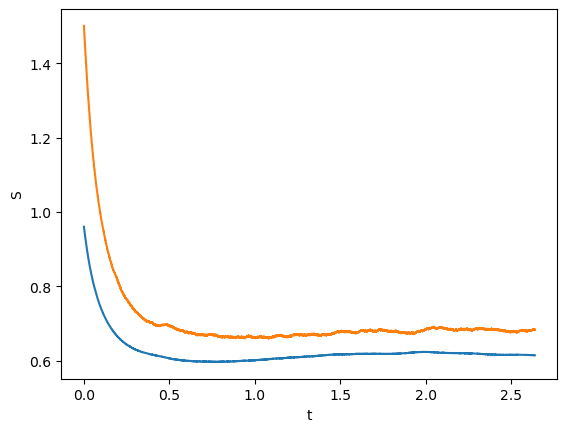

In [15]:
#edge_converged=edge_state.loc[edge_state['time']>0.5]
#edge_control['AMOC'] = edge_control['T']-edge_control['S']
#edge_control.head()
sns.lineplot(data=edge_state,x='t',y='S')
sns.lineplot(data=edge_state,x='t',y='T')

In [28]:
edge_control.head()
edge_control['atmosphere']=(edge_control['Corresponding x value']**2+edge_control['Corresponding y value']**2
                            + edge_control['Corresponding z value']**2)
edge_cut=edge_control.loc[edge_control['Run name']>10]
edge_converged=edge_state.loc[edge_state['t']>0.5]

In [5]:
edge_state.head()
edge_converged['atmosphere']=(edge_converged['x']**2+edge_converged['y']**2
                            + edge_converged['z']**2)

In [ ]:
#make 3D plot of edge, AMOC on, AMOC off with T,S, and atmosphere combined variable

T= np.concatenate([np.array(edge_converged['T']),np.array(edge_cut['Corresponding T value'])])
S= np.concatenate([np.array(edge_converged['S']),np.array(edge_cut['Corresponding S Value'])])
atmosphere= np.concatenate([np.array(edge_converged['atmosphere']),np.array(edge_cut['atmosphere'])])

cmap = cm.get_cmap('plasma')
color1 = cmap(0.)  # for condition 1
color2 = cmap(0.5)  # for condition 2
color3 = cmap(0.75)  # for condition 3
colors=[]

for t, s in zip(T, S):
    if t < 0.65 and s < 0.5:
        colors.append(color1)
    elif t >= 0.65 and s < 0.71:
        colors.append(color2)
    else:
        colors.append(color3)

fig2 = plt.figure()
ax2  = fig2.add_subplot(111, projection='3d')
surf2 = ax2.scatter(T, S, atmosphere,
                        color=colors)
ax2.set_xlabel('$T$',labelpad=10)
ax2.set_ylabel('$S$',labelpad=10)
ax2.set_zlabel('$X^2+Y^2+Z^2$',rotation=90)
ax2.set_xticks([0.75, 0.7, 0.65,0.6,0.55])
ax2.set_yticks([0.4, 0.5, 0.6,0.7])
ax2.set_zticks([0, 2, 4,6])

patch1 = mpatches.Patch(color=color1, label='AMOC on')
patch2 = mpatches.Patch(color=color2, label='Edge')
patch3 = mpatches.Patch(color=color3, label='AMOC off')
ax2.legend(handles=[patch1, patch2, patch3])
ax2.view_init(elev=30, azim=-45)
plt.tight_layout()
#plt.show()
plt.savefig("3D_edge.png")

/var/folders/v1/ymptnwwx3x1b7_mw0nns09wr0000gn/T/ipykernel_11454/799886267.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma')


In [ ]:
#make 2D and 3D scatter plots to show AMOC on/off and salinity-driven transitions in one plot
#dictionary of files and their transition periods
salt_transp = {"salt_40y_1000traj_8000k.csv": {"start": 10, "end": 12}, "salt_40y_1000traj_7000k.csv": {"start": 8, "end": 11},
               "salt_40y_1000traj_9000k.csv": {"start": 19, "end": 21}, "salt_40y_200traj_8000k.csv": {"start": 15, "end": 19},
               "salt_40y_200traj_7000k.csv": {"start": 28, "end": 31}, "salt_40y_200traj_9000k.csv": {"start": 27, "end": 29}}
#start = d["range"]["start"]; end = d["range"]["end"]
folder_path='salts/useful_transitions'
shifted_dfs=[]
ks=[]
for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        print(file)
        #get transition time periods
        start = salt_transp[file]['start']
        end   = salt_transp[file]['end']
        year_col = 'Run name'   
        
        #get variables from file name
        name = file.replace(".csv", "")
        _,  years, traj, seed = name.split("_")
    
        years = int(years.replace("y", ""))
        traj  = int(traj.replace("traj", ""))
        seed  = int(seed.replace("k", ""))
    
        df = pd.read_csv(os.path.join(folder_path, file))
        print(df['k'].unique())
        shifted_dfs.append(df)
    
        #get ks in list
        ks.append(seed)
    
        # mask rows in the transition period
        start_mask = df[year_col] == start
        end_mask   = df[year_col] == end

    plt.figure()
    
    ax = plt.gca()
    # faint background line for context
    ax.plot(df['Corresponding S Value'], df['Corresponding T value'],
            color="#d9d9d9", linewidth=1.0, zorder=1)
    
    # colored instanton / trajectory gradient by time (use a numeric column, e.g. Year)
    sc = ax.scatter(df['Corresponding S Value'], df['Corresponding T value'],
                    c=df['Run name'], cmap='plasma', s=40, zorder=2)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Year')

    # if exact years not present, use nearest
    if not start_mask.any():
        start_row = df.iloc[(df[year_col] - start).abs().argmin()]
        s_start, t_start = start_row['Corresponding S Value'], start_row['Corresponding T value']
    else:
        s_start = df.loc[start_mask, 'Corresponding S Value'].mean()
        t_start = df.loc[start_mask, 'Corresponding T value'].mean()
    
    if not end_mask.any():
        end_row = df.iloc[(df[year_col] - end).abs().argmin()]
        s_end, t_end = end_row['Corresponding S Value'], end_row['Corresponding T value']
    else:
        s_end = df.loc[end_mask, 'Corresponding S Value'].mean()
        t_end = df.loc[end_mask, 'Corresponding T value'].mean()


    ax.scatter(edge_converged['S'], edge_converged['T'],
               facecolor='#2b2b2b', edgecolor='#2b2b2b',marker='o', s=40, linewidth=0.05,
               label='edge state', zorder=6)

    # plot straight line between the two representative points
    ax.plot([s_start, s_end], [t_start, t_end],
            color='#006d77', linewidth=2.5, solid_capstyle='butt', zorder=4,label="transition")

    ax.scatter([s_start, s_end], [t_start, t_end], marker='x',color='#004b57', s=40, zorder=5)
    
    # grid on
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.4)
    
    plt.title(f"Transition Path and Edge State (Salinity Forcing)")
    plt.xlabel('Salinity')
    plt.ylabel('Temperature')
    ax.legend()

    #if (file=='salt_40y_200traj_7000k.csv'):
    plt.savefig(f"edge_instanton_salinity_{traj}{seed}.png")
    #plt.show()
    #plt.close()

In [ ]:
#make 2D and 3D scatter plots to show AMOC on/off and salinity-driven transitions in one plot
amoc_transp = {"metadata_trans_off1st_40y_200traj_-2000k.csv": {"start": 24, "end": 27},
               "metadata_trans_off_40y_200traj_-500k.csv": {"start": 12, "end": 15},
               "metadata_trans_off1st_40y_1000traj_-500k.csv": {"start": 7, "end": 9}, 
               "metadata_trans_off1st_40y_200traj_-1000k.csv": {"start": 20, "end": 23},
               "metadata_trans_off1st_40y_1000traj_-2000k.csv": {"start": 9, "end": 11}, 
               "metadata_trans_off1st_40y_1000traj_-1000k.csv": {"start": 7, "end": 10}}
folder_path='exp_names_shifted/useful_transitions'
shifted_dfs=[]
ks=[]
for file in os.listdir(folder_path):
    print(file)
    

    #get variables from file name
    if file.endswith(".csv"):
        name = file.replace(".csv", "")
        _,_,_,  years, traj, seed = name.split("_")
    
        years = int(years.replace("y", ""))
        traj  = int(traj.replace("traj", ""))
        seed  = int(seed.replace("k", ""))
    
        df = pd.read_csv(os.path.join(folder_path, file))
        print(df['k'].unique())
        shifted_dfs.append(df)
    
        #get ks in list
        ks.append(seed)

        #get transition time periods
        start = amoc_transp[file]['start']
        end   = amoc_transp[file]['end']
        year_col = 'Run name'  

        # mask rows in the transition period
        start_mask = df[year_col] == start
        end_mask   = df[year_col] == end

        
    plt.figure()
    ax = plt.gca()
    # faint background line for context
    ax.plot(df['Corresponding S Value'], df['Corresponding T value'],
            color="#d9d9d9", linewidth=1.0, zorder=1)
    
    # colored instanton / trajectory gradient by time (use a numeric column, e.g. Year)
    sc = ax.scatter(df['Corresponding S Value'], df['Corresponding T value'],
                    c=df['Run name'], cmap='plasma', s=40, edgecolors='none', zorder=2)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Year')

    ax.scatter(edge_converged['S'], edge_converged['T'],
               color='#2b2b2b', edgecolor='#2b2b2b',marker='o', s=40, linewidth=1.2,
               label='edge state', zorder=6)

        # if exact years not present, use nearest
    if not start_mask.any():
        start_row = df.iloc[(df[year_col] - start).abs().argmin()]
        s_start, t_start = start_row['Corresponding S Value'], start_row['Corresponding T value']
    else:
        s_start = df.loc[start_mask, 'Corresponding S Value'].mean()
        t_start = df.loc[start_mask, 'Corresponding T value'].mean()
    
    if not end_mask.any():
        end_row = df.iloc[(df[year_col] - end).abs().argmin()]
        s_end, t_end = end_row['Corresponding S Value'], end_row['Corresponding T value']
    else:
        s_end = df.loc[end_mask, 'Corresponding S Value'].mean()
        t_end = df.loc[end_mask, 'Corresponding T value'].mean()

    # plot straight line between the two representative points
    ax.plot([s_start, s_end], [t_start, t_end],
            color='#006d77', linewidth=2.5, solid_capstyle='butt', zorder=4,label="transition")

    ax.scatter([s_start, s_end], [t_start, t_end], marker='x',color='#004b57', s=40, zorder=5)
    
    # grid on
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.4)
    plt.title(f"Transition Path and Edge State (AMOC Forcing)")
    plt.xlabel('Salinity')
    plt.ylabel('Temperature')
    ax.legend()
    
    
    '''#legend
    legend_elements = [
        Line2D([0], [0], marker='X', linestyle='None',
               label='AMOC', markersize=8,
                markerfacecolor=amoc_color,
                markeredgecolor=amoc_color,)
    ]
    '''
    plt.savefig(f"edge_instanton_amoc_{traj}{seed}.png")
    #plt.show()
    #plt.close()

In [ ]:
'''
the same plots again but salinity vs x^2+y^2+z^2, and temperature vs the same
'''
#make 2D and 3D scatter plots to show AMOC on/off and salinity-driven transitions in one plot
#dictionary of files and their transition periods
salt_transp = {"salt_40y_1000traj_8000k.csv": {"start": 10, "end": 12}, "salt_40y_1000traj_7000k.csv": {"start": 8, "end": 11},
               "salt_40y_1000traj_9000k.csv": {"start": 19, "end": 21}, "salt_40y_200traj_8000k.csv": {"start": 15, "end": 19},
               "salt_40y_200traj_7000k.csv": {"start": 28, "end": 31}, "salt_40y_200traj_9000k.csv": {"start": 27, "end": 29}}
#start = d["range"]["start"]; end = d["range"]["end"]
folder_path='salts/useful_transitions'
shifted_dfs=[]
ks=[]
for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        print(file)
        #get transition time periods
        start = salt_transp[file]['start']
        end   = salt_transp[file]['end']
        year_col = 'Run name'   
        
        #get variables from file name
        name = file.replace(".csv", "")
        _,  years, traj, seed = name.split("_")
    
        years = int(years.replace("y", ""))
        traj  = int(traj.replace("traj", ""))
        seed  = int(seed.replace("k", ""))
    
        df = pd.read_csv(os.path.join(folder_path, file))
        print(df['k'].unique())
        shifted_dfs.append(df)
    
        #get ks in list
        ks.append(seed)
    
        # mask rows in the transition period
        start_mask = df[year_col] == start
        end_mask   = df[year_col] == end

        #make atmospheric column
        df['atmosphere'] = df['Corresponding x value']**2 + df['Corresponding y value']**2 + df['Corresponding z value']**2

    plt.figure()
    
    ax = plt.gca()
    # faint background line for context
    ax.plot(df['Corresponding S Value'], df['atmosphere'],
            color="#d9d9d9", linewidth=1.0, zorder=1)
    
    # colored instanton / trajectory gradient by time (use a numeric column, e.g. Year)
    sc = ax.scatter(df['Corresponding S Value'], df['atmosphere'],
                    c=df['Run name'], cmap='plasma', s=40, zorder=2)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Year')

    # if exact years not present, use nearest
    if not start_mask.any():
        start_row = df.iloc[(df[year_col] - start).abs().argmin()]
        s_start, t_start = start_row['Corresponding S Value'], start_row['atmosphere']
    else:
        s_start = df.loc[start_mask, 'Corresponding S Value'].mean()
        t_start = df.loc[start_mask, 'atmosphere'].mean()
    
    if not end_mask.any():
        end_row = df.iloc[(df[year_col] - end).abs().argmin()]
        s_end, t_end = end_row['Corresponding S Value'], end_row['atmosphere']
    else:
        s_end = df.loc[end_mask, 'Corresponding S Value'].mean()
        t_end = df.loc[end_mask, 'atmosphere'].mean()

    #create atmosphere column for edge state
    edge_converged['atmosphere'] = edge_converged['x']**2 + edge_converged['y']**2 + edge_converged['z']**2
    ax.plot(edge_converged['S'], edge_converged['atmosphere'],alpha=0.5,label='edge state',color='#2b2b2b')
             #  facecolor='#2b2b2b', edgecolor='#2b2b2b',marker='o', s=40, linewidth=0.05,
            #   label='edge state', zorder=6, alpha=0.5)

    # plot straight line between the two representative points
    #ax.plot([s_start, s_end], [t_start, t_end],
            #color='#006d77', linewidth=2.5, solid_capstyle='butt', zorder=4,label="transition")

    #ax.scatter([s_start, s_end], [t_start, t_end], marker='x',color='#004b57', s=40, zorder=5)
    
    # grid on
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.4)
    
    plt.title(f"Transition Path and Edge State (Salinity Forcing)")
    plt.xlabel('Salinity')
    plt.ylabel(r'$x^{2} + y^{2} + z^{2}$')
    ax.legend()

    if (file=='salt_40y_200traj_9000k.csv'):
        plt.savefig(f"edge_instanton_salinity_xyz_{traj}{seed}.png")
    #plt.show()
    #plt.close()

In [ ]:
#make 2D and 3D scatter plots to show AMOC on/off and salinity-driven transitions in one plot
amoc_transp = {"metadata_trans_off1st_40y_200traj_-2000k.csv": {"start": 24, "end": 27},
               "metadata_trans_off_40y_200traj_-500k.csv": {"start": 12, "end": 15},
               "metadata_trans_off1st_40y_1000traj_-500k.csv": {"start": 7, "end": 9}, 
               "metadata_trans_off1st_40y_200traj_-1000k.csv": {"start": 20, "end": 23},
               "metadata_trans_off1st_40y_1000traj_-2000k.csv": {"start": 9, "end": 11}, 
               "metadata_trans_off1st_40y_1000traj_-1000k.csv": {"start": 7, "end": 10}}
folder_path='exp_names_shifted/useful_transitions'
shifted_dfs=[]
ks=[]
for file in os.listdir(folder_path):
    print(file)
    

    #get variables from file name
    if file.endswith(".csv"):
        name = file.replace(".csv", "")
        _,_,_,  years, traj, seed = name.split("_")
    
        years = int(years.replace("y", ""))
        traj  = int(traj.replace("traj", ""))
        seed  = int(seed.replace("k", ""))
    
        df = pd.read_csv(os.path.join(folder_path, file))
        print(df['k'].unique())
        shifted_dfs.append(df)
    
        #get ks in list
        ks.append(seed)

        #get transition time periods
        start = amoc_transp[file]['start']
        end   = amoc_transp[file]['end']
        year_col = 'Run name'  

        # mask rows in the transition period
        start_mask = df[year_col] == start
        end_mask   = df[year_col] == end

        #make atmospheric column
        df['atmosphere'] = df['Corresponding x value']**2 + df['Corresponding y value']**2 + df['Corresponding z value']**2

    plt.figure()
    ax = plt.gca()
    # faint background line for context
    ax.plot(df['Corresponding T value'], df['atmosphere'],
            color="#d9d9d9", linewidth=1.0, zorder=1)
    
    # colored instanton / trajectory gradient by time (use a numeric column, e.g. Year)
    sc = ax.scatter(df['Corresponding T value'], df['atmosphere'],
                    c=df['Run name'], cmap='plasma', s=40, edgecolors='none', zorder=2)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Year')

    edge_converged['atmosphere'] = edge_converged['x']**2 + edge_converged['y']**2 + edge_converged['z']**2
    ax.plot(edge_converged['T'], edge_converged['atmosphere'],label='edge state',
               color='#2b2b2b',alpha=0.5,zorder=3)
               #edgecolor='#2b2b2b',marker='o', s=40, linewidth=1.2,
               #label='edge state', zorder=6)

        # if exact years not present, use nearest
    if not start_mask.any():
        start_row = df.iloc[(df[year_col] - start).abs().argmin()]
        s_start, t_start = start_row['Corresponding T value'], start_row['atmosphere']
    else:
        s_start = df.loc[start_mask, 'Corresponding T value'].mean()
        t_start = df.loc[start_mask, 'atmosphere'].mean()
    
    if not end_mask.any():
        end_row = df.iloc[(df[year_col] - end).abs().argmin()]
        s_end, t_end = end_row['Corresponding T value'], end_row['atmosphere']
    else:
        s_end = df.loc[end_mask, 'Corresponding T value'].mean()
        t_end = df.loc[end_mask, 'atmosphere'].mean()

    # plot straight line between the two representative points
    #ax.plot([s_start, s_end], [t_start, t_end],
            #color='#006d77', linewidth=2.5, solid_capstyle='butt', zorder=4,label="transition")

    #ax.scatter([s_start, s_end], [t_start, t_end], marker='x',color='#004b57', s=40, zorder=5)
    
    # grid on
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.4)
    plt.title(f"Transition Path and Edge State (AMOC Forcing)")
    plt.xlabel('Temperature')
    plt.ylabel(r'$x^{2} + y^{2} + z^{2}$')
    ax.legend()
    
    
    '''#legend
    legend_elements = [
        Line2D([0], [0], marker='X', linestyle='None',
               label='AMOC', markersize=8,
                markerfacecolor=amoc_color,
                markeredgecolor=amoc_color,)
    ]
    '''
    if (file=='metadata_trans_off1st_40y_200traj_-2000k.csv'):
        print('yes')
        plt.savefig(f"edge_instanton_amoc_xyz_{traj}{seed}.png")
    #plt.show()
    #plt.close()